## Agentic ai not diurectly through rag pipleine 

## Through SQL

In [93]:
import sqlite3

In [94]:
connection = sqlite3.connect("mydb.db")


In [95]:
connection

In [96]:
table_creation_query = """
CREATE TABLE IF NOT EXISTS employees (
    emp_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    hire_date TEXT NOT NULL,
    salary REAL NOT NULL
);
"""

In [97]:
table_creation_query2 = """
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    phone TEXT
);
"""

In [98]:
table_creation_query3 = """
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers (customer_id)
);
"""

In [99]:
cursor = connection.cursor()

In [100]:
cursor.execute(table_creation_query)
cursor.execute(table_creation_query2)
cursor.execute(table_creation_query3)


In [101]:
insert_query = """
INSERT INTO employees (emp_id, first_name, last_name, email, hire_date, salary)
VALUES (?, ?, ?, ?, ?, ?);
"""

insert_query_customers = """
INSERT INTO customers (customer_id, first_name, last_name, email, phone)
VALUES (?, ?, ?, ?, ?);
"""

insert_query_orders = """
INSERT INTO orders (order_id, customer_id, order_date, amount)
VALUES (?, ?, ?, ?);
"""

In [102]:
employee_data = [
    (1, "Sunny", "Savita", "sunny.sv@abc.com", "2023-06-01", 50000.00),
    (2, "Arhun", "Meheta", "arhun.me@gmail.com", "2022-04-15", 60000.00),
    (3, "Alice", "Johnson", "alice.johnson@jpg.com", "2021-09-30", 55000.00),
    (4, "Bob", "Brown", "bob.brown@uio.com", "2020-01-20", 45000.00),
]

customers_data = [
    (1, "John", "Doe", "john.doe@example.com", "1234567890"),
    (2, "Jane", "Smith", "jane.smith@example.com", "9876543210"),
    (3, "Emily", "Davis", "emily.davis@example.com", "4567891230"),
    (4, "Michael", "Brown", "michael.brown@example.com", "7894561230"),
]

orders_data = [
    (1, 1, "2023-12-01", 250.75),
    (2, 2, "2023-11-20", 150.50),
    (3, 3, "2023-11-25", 300.00),
    (4, 4, "2023-12-02", 450.00),
]

In [106]:
cursor.executemany(insert_query,employee_data)
cursor.executemany(insert_query_customers,customers_data)
cursor.executemany(insert_query_orders,orders_data)

In [107]:
connection.commit()

In [108]:
cursor.execute("select * from orders;")

In [109]:
for row in cursor.fetchall():
    print(row)

(1, 1, '2023-12-01', 250.75)
(2, 2, '2023-11-20', 150.5)
(3, 3, '2023-11-25', 300.0)
(4, 4, '2023-12-02', 450.0)


In [110]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///mydb.db")

In [111]:
db

In [112]:
db.dialect

'sqlite'

# SQL Dialect

## What is a SQL Dialect?

A **SQL dialect** is the specific version or flavor of SQL used by a Database Management System (DBMS).

Although all databases use SQL, each database has its own syntax, functions, and features.

---

## Common SQL Dialects

| Database | SQL Dialect |
|----------|-------------|
| SQLite | SQLite SQL |
| MySQL | MySQL SQL |
| PostgreSQL | PostgreSQL SQL |
| Oracle | Oracle SQL |
| Microsoft SQL Server | T-SQL (Transact-SQL) |

---

## Example

### SQLite

```sql
CREATE TABLE users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT
);
```

### MySQL

```sql
CREATE TABLE users (
    id INT AUTO_INCREMENT PRIMARY KEY,
    name VARCHAR(100)
);
```

### PostgreSQL

```sql
CREATE TABLE users (
    id SERIAL PRIMARY KEY,
    name VARCHAR(100)
);
```

Although these queries perform the same task, the syntax differs because each database uses a different SQL dialect.

---

# SQL Dialect in LangChain

When creating a database connection:

```python
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///mydb.db")
```

You can check the database dialect using:

```python
print(db.dialect)
```

**Output**

```text
sqlite
```

---

## Why is SQL Dialect Important?

Large Language Models (LLMs) generate SQL queries based on the database dialect.

For example, to retrieve the first 10 records:

| Database | Query |
|----------|-------|
| SQLite | `SELECT * FROM users LIMIT 10;` |
| MySQL | `SELECT * FROM users LIMIT 10;` |
| PostgreSQL | `SELECT * FROM users LIMIT 10;` |
| SQL Server | `SELECT TOP 10 * FROM users;` |
| Oracle | `SELECT * FROM users FETCH FIRST 10 ROWS ONLY;` |

If the wrong dialect is used, the SQL query may fail.

---

## Key Points

- A **SQL dialect** is the database-specific version of SQL.
- Every DBMS has its own syntax and functions.
- LangChain automatically detects the SQL dialect.
- The database dialect helps LLMs generate correct SQL queries.
- Always verify the dialect before executing generated SQL queries.

---

## Check the Current Database Dialect

```python
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///mydb.db")

print("Database Dialect:", db.dialect)
```

**Expected Output**

```text
Database Dialect: sqlite
```

In [113]:
db.get_usable_table_names()

['customers', 'employees', 'orders']

In [114]:
from dotenv import load_dotenv
load_dotenv()

True

In [115]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [116]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit


In [117]:
toolkit = SQLDatabaseToolkit(db=db,llm=llm)

In [118]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000024DC53B5090>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000024DC53B5090>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000024DC53B5090>),
 QuerySQLCheckerTool(description='Use this tool to 

In [119]:
tools = toolkit.get_tools()
for tool in tools:
    print(tool.name)

sql_db_query
sql_db_schema
sql_db_list_tables
sql_db_query_checker


In [120]:
list_tables_tool = next(
    (tool for tool in tools if tool.name == "sql_db_list_tables"),
    None
)

# Understanding `next()` with Generator Expression

## Code

```python
list_tables_tool = next(
    (tool for tool in tools if tool.name == "sql_db_list_tables"),
    None
)
```

---

# What does this code do?

This line searches through the `tools` list and returns the **first tool** whose name is `"sql_db_list_tables"`.

If no such tool exists, it returns `None`.

---

# Breaking Down the Code

### 1. `tools`

`tools` is a list containing all the tools created by the SQL toolkit.

Example:

```python
tools = [
    Tool(name="sql_db_query"),
    Tool(name="sql_db_schema"),
    Tool(name="sql_db_list_tables"),
    Tool(name="sql_db_query_checker")
]
```

---

### 2. Generator Expression

```python
(tool for tool in tools if tool.name == "sql_db_list_tables")
```

This is called a **generator expression**.

It loops through every tool in the `tools` list.

For each tool, it checks:

```python
tool.name == "sql_db_list_tables"
```

If the condition is `True`, that tool is produced.

It is similar to writing:

```python
for tool in tools:
    if tool.name == "sql_db_list_tables":
        print(tool)
```

The difference is that a generator **does not create a new list**. It produces values one at a time, making it memory efficient.

---

### 3. `next()`

The syntax is:

```python
next(iterator, default_value)
```

- **iterator** → Something that can be iterated over (like a generator).
- **default_value** → Returned if no item is found.

In this example:

```python
next(
    (tool for tool in tools if tool.name == "sql_db_list_tables"),
    None
)
```

means:

> "Return the first tool whose name is `sql_db_list_tables`. If no such tool exists, return `None`."

---

# Equivalent Code Using a `for` Loop

The above code is equivalent to:

```python
list_tables_tool = None

for tool in tools:
    if tool.name == "sql_db_list_tables":
        list_tables_tool = tool
        break
```

### Explanation

- Start with `list_tables_tool = None`.
- Loop through every tool.
- If the tool's name matches `"sql_db_list_tables"`, save it.
- Stop searching using `break`.

---

# Example

Suppose:

```python
tools = [
    Tool(name="sql_db_query"),
    Tool(name="sql_db_schema"),
    Tool(name="sql_db_list_tables"),
    Tool(name="sql_db_query_checker")
]
```

Then,

```python
list_tables_tool = next(
    (tool for tool in tools if tool.name == "sql_db_list_tables"),
    None
)
```

returns:

```python
Tool(name="sql_db_list_tables")
```

---

# What if the tool is not found?

Suppose:

```python
tools = [
    Tool(name="sql_db_query"),
    Tool(name="sql_db_schema")
]
```

Then,

```python
list_tables_tool = next(
    (tool for tool in tools if tool.name == "sql_db_list_tables"),
    None
)
```

returns:

```python
None
```

This prevents an error and lets your program safely check whether the tool exists.

---

# Why Use `next()`?

Using `next()` with a generator expression is:

- ✅ Short and readable
- ✅ Faster because it stops after finding the first match
- ✅ Memory efficient because it doesn't create a new list
- ✅ Common Python practice for retrieving a single matching item

---

# Key Points

- `tools` is a list of available tools.
- The generator expression searches for a tool with a specific name.
- `next()` returns the **first matching tool**.
- If no match is found, `None` is returned.
- This is equivalent to using a `for` loop with `break`, but is more concise and efficient.

In [121]:
list_tables_tool

ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000024DC53B5090>)

In [122]:
get_schema_tool = next(
    (tool for tool in tools if tool.name == "sql_db_schema"),
    None
)

In [123]:
list_tables_tool.invoke("")

'customers, employees, orders'

In [124]:
get_schema_tool.invoke("customers")

'\nCREATE TABLE customers (\n\tcustomer_id INTEGER, \n\tfirst_name TEXT NOT NULL, \n\tlast_name TEXT NOT NULL, \n\temail TEXT NOT NULL, \n\tphone TEXT, \n\tPRIMARY KEY (customer_id), \n\tUNIQUE (email)\n)\n\n/*\n3 rows from customers table:\ncustomer_id\tfirst_name\tlast_name\temail\tphone\n1\tJohn\tDoe\tjohn.doe@example.com\t1234567890\n2\tJane\tSmith\tjane.smith@example.com\t9876543210\n3\tEmily\tDavis\temily.davis@example.com\t4567891230\n*/'

In [125]:
print(get_schema_tool.invoke("customers"))


CREATE TABLE customers (
	customer_id INTEGER, 
	first_name TEXT NOT NULL, 
	last_name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	phone TEXT, 
	PRIMARY KEY (customer_id), 
	UNIQUE (email)
)

/*
3 rows from customers table:
customer_id	first_name	last_name	email	phone
1	John	Doe	john.doe@example.com	1234567890
2	Jane	Smith	jane.smith@example.com	9876543210
3	Emily	Davis	emily.davis@example.com	4567891230
*/


In [126]:
from langchain_core.tools import tool

@tool
def db_query_tool(query: str) -> str:
    """
    Execute a SQL query against the database and return the result.
    If the query is invalid or returns no result, an error message will be returned.
    In case of an error, the user is advised to rewrite the query and try again.
    """
    result = db.run_no_throw(query)

    if not result:
        return "Error: Query failed. Please rewrite your query and try again."

    return result

In [127]:
db_query_tool.invoke("Select * from Employees;")

"[(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0), (2, 'Arhun', 'Meheta', 'arhun.me@gmail.com', '2022-04-15', 60000.0), (3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0), (4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)]"

In [128]:
db.run("Select * from Employees;")

"[(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0), (2, 'Arhun', 'Meheta', 'arhun.me@gmail.com', '2022-04-15', 60000.0), (3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0), (4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)]"

### Difference Between `db.run()` and `db.run_no_throw()`

| `db.run()` | `db.run_no_throw()` |
|------------|---------------------|
| Executes the SQL query. | Executes the SQL query. |
| Raises an exception if the query is invalid. | Does not raise an exception. |
| Stops the program on errors unless handled. | Returns the error as a string and continues execution. |
| Best for debugging. | Best for AI agents and production applications. |

**Example**

```python
# Raises an exception
db.run("SELECT * FORM employees;")
```

```python
# Returns an error message
db.run_no_throw("SELECT * FORM employees;")
```

**Key Point:**  
- `db.run()` → **Throws exceptions** on errors.  
- `db.run_no_throw()` → **Returns error messages** without crashing the program.

# query_check 

# query_generation

In [129]:
from langchain_core.prompts import ChatPromptTemplate

query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQLite query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check."""

query_check_prompt = ChatPromptTemplate.from_messages(
    [("system", query_check_system), ("placeholder", "{messages}")]
)

query_check = query_check_prompt | llm.bind_tools([db_query_tool])

query_check.invoke(
    {"messages": [("user", "SELECT * FROM Employees LIMIT 5;")]}
)

AIMessage(content="SELECT * FROM Employees LIMIT 5; \n\nNo issues found in the query. It will return the first 5 rows from the 'Employees' table.\n\n", additional_kwargs={'tool_calls': [{'id': 'n45whs5g0', 'function': {'arguments': '{"query":"SELECT * FROM Employees LIMIT 5;"}', 'name': 'db_query_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 432, 'total_tokens': 484, 'completion_time': 0.086866457, 'completion_tokens_details': None, 'prompt_time': 0.043945959, 'prompt_tokens_details': None, 'queue_time': 0.05663182, 'total_time': 0.130812416}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5a0e-66bb-7901-8e18-b626aeb0bc49-0', tool_calls=[{'name': 'db_query_tool', 'args': {'query': 'SELECT * FROM Employees LIMIT 5;'}, 'id': 'n45whs5g0', 'type': 'tool_call'}], invalid_tool_calls

In [130]:
query_check.invoke({"message": [("user","SELECT * FROM Employees LIMIT 5;")]})

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7gr6mm1dy', 'function': {'arguments': '{"query":"SELECT * FROM customers WHERE country=\'USA\' AND age NOT IN (SELECT age FROM sales)"}', 'name': 'db_query_tool'}, 'type': 'function'}, {'id': 'ptryw3f32', 'function': {'arguments': '{"query":"SELECT * FROM orders AS o INNER JOIN customers AS c ON o.customer_id = c.id WHERE o.total \\u003e 100 AND c.country=\'USA\'"}', 'name': 'db_query_tool'}, 'type': 'function'}, {'id': 'pzfzn1qr8', 'function': {'arguments': '{"query":"SELECT * FROM employees WHERE salary BETWEEN 50000 AND 60000 EXCLUSIVE"}', 'name': 'db_query_tool'}, 'type': 'function'}, {'id': '65rnwcqh4', 'function': {'arguments': '{"query":"SELECT * FROM products WHERE price = 9.99 AND category=\'Electronics\' AND stock_level \\u003e 100 AND store_id = 1 AND product_name = \'Laptop\'"}', 'name': 'db_query_tool'}, 'type': 'function'}, {'id': 'kfeec8qmx', 'function': {'arguments': '{"query":"SELECT product_name, SUM(pric

In [131]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

class SubmitFinalAnswer(BaseModel):
    """Submit the final answer to the user based on the query results."""

    final_answer: str = Field(
        ...,
        description="The final answer to the user"
    )


# Add a node for a model to generate a query based on the question and schema.
query_gen_system = """You are a SQL expert with a strong attention to detail.

Given an input question, output a syntactically correct SQLite query to run,
then look at the results of the query and return the answer.

DO NOT call any tool besides SubmitFinalAnswer to submit the final answer.

When generating the query:

- Output the SQL query that answers the input question without a tool call.

- Unless the user specifies a specific number of examples they wish to obtain,
  always limit your query to at most 5 results.

- You can order the results by a relevant column to return the most
  interesting examples in the database.

- Never query for all the columns from a specific table,
  only ask for the relevant columns given the question.

- If you get an error while executing a query, rewrite the query and try again.

- If you get an empty result set, you should try to rewrite the query
  to get a non-empty result set.

- NEVER make stuff up if you don't have enough information to answer the query...
  just say you don't have enough information.

- If you have enough information to answer the input question,
  simply invoke the appropriate tool to submit the final answer to the user.

- DO NOT make any DML statements
  (INSERT, UPDATE, DELETE, DROP etc.) to the database.
  Do not return any SQL query except answer.
"""

query_gen_prompt = ChatPromptTemplate.from_messages(
    [("system", query_gen_system), ("placeholder", "{messages}")]
)

query_gen = query_gen_prompt | llm.bind_tools([SubmitFinalAnswer])

### Time for Langgraph pipeline


In [212]:
from typing import TypedDict
from typing_extensions import Annotated
from typing import Any
from langchain_core.runnables import RunnableWithFallbacks

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [229]:
from langchain_core.messages import AIMessage,ToolMessage

def first_tool_call(state: State):
    return {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "sql_db_list_tables",
                        "args": {},
                        "id": "tool_abcd123",
                    }
                ],
            )
        ]
    }

def error_tool_call(State:State):
    pass

In [230]:
def handle_tool_error(State:State):
    error = State.get("error")
    tool_calls = State["message"][-1].tool_calls
    return {
        "messages":[
            ToolMessage(content=f"Error : {repr(error)}\n please fix your mistakes", 
                        tool_call_id = tc["id"],)
                        for tc in tool_calls
        ]
    }

In [231]:
from langgraph.prebuilt import ToolNode
from langchain_core.runnables import RunnableLambda
def create_tool_node_with_fallback(tools:list)-> RunnableWithFallbacks[Any,dict]:
    return ToolNode(tools).with_fallbacks([RunnableLambda(handle_tool_error)],exception_key="error")


In [232]:
def query_gen_node(state: State):
    message = query_gen.invoke(state)

    # Sometimes, the LLM will hallucinate and call the wrong tool.
    # We need to catch this and return an error message.
    tool_messages = []

    if message.tool_calls:
        for tc in message.tool_calls:
            if tc["name"] != "SubmitFinalAnswer":
                tool_messages.append(
                    ToolMessage(
                        content=(
                            f"Error: The wrong tool was called: {tc['name']}. "
                            "Please fix your mistakes. Remember to only call "
                            "SubmitFinalAnswer to submit the final answer."
                        ),
                        tool_call_id=tc["id"],
                    )
                )
    else:
        tool_messages = []

    return {"messages": [message] + tool_messages}

In [233]:
from langgraph.graph import StateGraph, START, END

def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]

    if getattr(last_message, "tool_calls", None):
        return END

    if last_message.content.startswith("Error:"):
        return "query_gen"
    else:
        return "correct_query"

In [234]:
def model_check_query(State:State):
    return {"messages": [query_check.invoke({"messages": [State["messages"][-1]]})]}

In [252]:

workflow = StateGraph(State)

In [253]:
workflow.add_node("first_tool_call",first_tool_call)
workflow.add_node("list_table_tool",create_tool_node_with_fallback([list_tables_tool]))
workflow.add_node("get_schema_tool",create_tool_node_with_fallback([get_schema_tool]))
model_get_schema = llm.bind_tools([get_schema_tool])
workflow.add_node(
    "model_get_schema",
    lambda state: {
        "messages": [model_get_schema.invoke(state["messages"])]
    },
)
workflow.add_node("query_gen",query_gen_node)
workflow.add_node("correct_query",model_check_query)
workflow.add_node("execute_query",create_tool_node_with_fallback([db_query_tool]))


In [254]:
workflow.add_edge(START,"first_tool_call")
workflow.add_edge("first_tool_call","list_table_tool")
workflow.add_edge("list_table_tool","model_get_schema")
workflow.add_edge("model_get_schema","get_schema_tool")
workflow.add_edge("get_schema_tool","query_gen")
workflow.add_conditional_edges(
    "query_gen",
    should_continue,
    {
        "query_gen": "query_gen",
        "correct_query": "correct_query",
        END: END,
    },
)
workflow.add_edge("correct_query","execute_query")
workflow.add_edge("execute_query","query_gen")


In [255]:
print(workflow.branches)

defaultdict(<class 'dict'>, {'query_gen': {'should_continue': BranchSpec(path=should_continue(tags=None, recurse=True, explode_args=False, func_accepts={}), ends={'query_gen': 'query_gen', 'correct_query': 'correct_query', '__end__': '__end__'}, input_schema=<class '__main__.State'>)}})


In [256]:
app = workflow.compile()


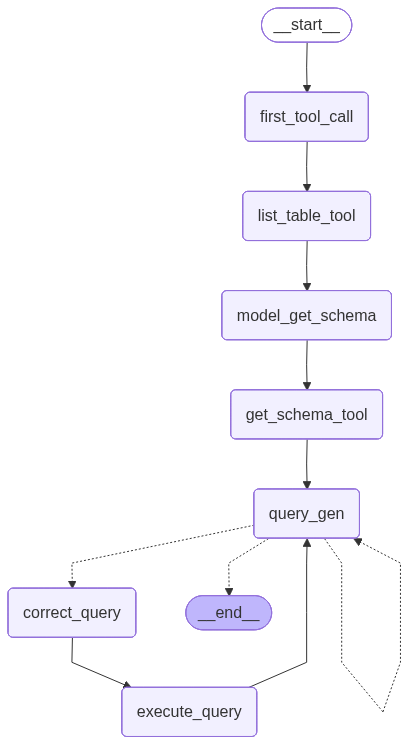

In [257]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [258]:
result = app.invoke(
    {
        "messages": [
            ("user", "List all customers with their emails.")
        ]
    }
)

In [261]:
result["messages"][-1].tool_calls[0]["args"]["final_answer"]

"['John Doe - john.doe@example.com', 'Jane Smith - jane.smith@example.com', 'Emily Davis - emily.davis@example.com', 'Michael Brown - michael.brown@example.com']"

### Difference Between `invoke()` and `stream()`

| `invoke()` | `stream()` |
|------------|------------|
| Returns the complete output at once. | Returns the output incrementally (chunk by chunk). |
| Waits until execution is finished. | Starts returning results immediately. |
| Best for short or single responses. | Best for long responses and real-time updates. |

**Example**

```python
# Returns the final response
result = chain.invoke({"question": "What is SQL?"})
print(result)
```

```python
# Streams the response step by step
for chunk in chain.stream({"question": "What is SQL?"}):
    print(chunk)
```

**Key Point:**
- `invoke()` → Complete response at once.
- `stream()` → Response is streamed progressively.